In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv('C:/Users/sushm/OneDrive/Desktop/iris_project/Iris.csv')

In [3]:
print(df.head(), "\n")

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa 



In [4]:
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print("Dropped 'Id' column.")

Dropped 'Id' column.


In [5]:
missing_values = df.isnull().sum().sum()
print(f"Total missing values found: {missing_values}")

Total missing values found: 0


In [6]:
duplicates = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates}")

Total duplicate rows found: 3


In [7]:
if duplicates > 0:
    df = df.drop_duplicates()
    print("Dropped duplicate rows.")

Dropped duplicate rows.


In [8]:
print(df.head(), "\n")

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa 



Generating Pairplot... (Close the image window to continue)


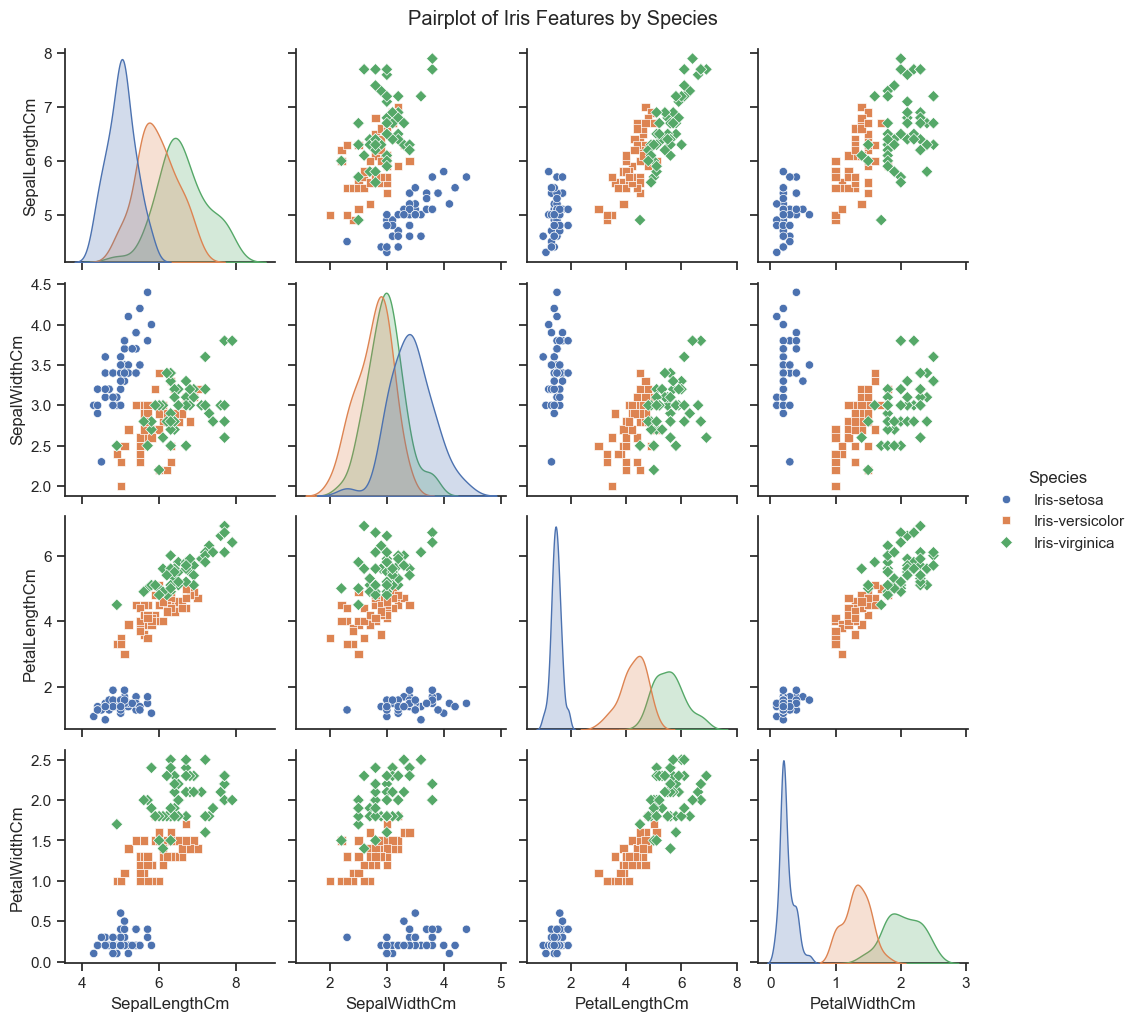

In [9]:
sns.set_theme(style="ticks")
print("Generating Pairplot... (Close the image window to continue)")
sns.pairplot(df, hue="Species", markers=["o", "s", "D"])
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

Generating Boxplot... (Close the image window to finish)


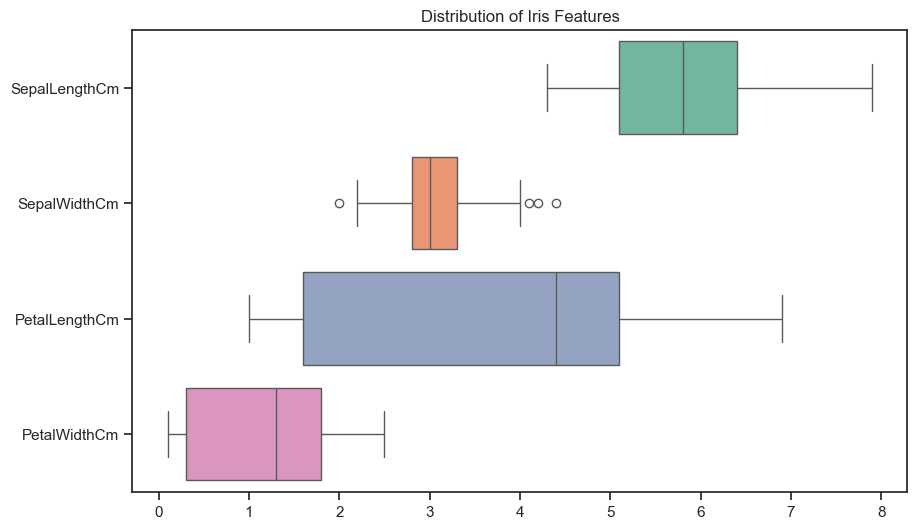

In [10]:
print("Generating Boxplot... (Close the image window to finish)")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('Species', axis=1), orient="h", palette="Set2")
plt.title("Distribution of Iris Features")
plt.show()

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [12]:
df = pd.read_csv('C:/Users/sushm/OneDrive/Desktop/iris_project/Cleaned_Iris.csv')

In [13]:
X = df.drop('Species', axis=1).values
y_strings = df['Species'].values

In [14]:
le = LabelEncoder()
y = le.fit_transform(y_strings)
target_names = le.classes_

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
predictions = knn_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model trained successfully. Accuracy on test set: {accuracy * 100:.2f}%")

Model trained successfully. Accuracy on test set: 93.33%
